In [2]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path(r"C:\Soilgrids")
DATA_DIR = BASE_DIR / 'data'
TDR_DIR = BASE_DIR / 'TDR_data'
RESULTS_DIR = BASE_DIR / 'resultados'
FIGURES_DIR = BASE_DIR / 'analysis' / 'results_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GPKG_PATH = DATA_DIR / 'Ubicacion_Estacion Principal.gpkg'
TDR_RAW_PATH = TDR_DIR / 'TDR_ladera_zhurucay_2021_09_2026_03.csv'
TDR_DAILY_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_avg.csv'
TDR_DAILY_MEAN_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors.csv'
TDR_CLEAN_PATH = RESULTS_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv'
SMAP_PATH = TDR_DIR / 'SMAP_RZ_clean.csv'
MISSING_DATES_PATH = RESULTS_DIR / 'missing_dates_daily_mean_all_sensors.csv'
MISSING_GAPS_PATH = RESULTS_DIR / 'missing_gaps_summary_daily_mean_all_sensors.csv'
COMPARISON_DAILY_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_daily.csv'
COMPARISON_OVERLAP_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_overlap_only.csv'


def normalize_dates(dataframe, column_name):
    dataframe = dataframe.copy()
    dataframe[column_name] = pd.to_datetime(dataframe[column_name]).dt.normalize()
    return dataframe


def save_figure(fig, filename, dpi=150):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Visualization saved to: {output_path}")
    return output_path


def load_smap_daily():
    smap = pd.read_csv(SMAP_PATH, parse_dates=['datetime'])
    smap = normalize_dates(smap, 'datetime')
    smap = smap.rename(columns={'datetime': 'Date'})
    return (
        smap.groupby('Date', as_index=False)['soil_moisture']
        .mean()
        .sort_values('Date')
    )


def load_tdr_clean():
    tdr = pd.read_csv(TDR_CLEAN_PATH, parse_dates=['Date'])
    tdr = normalize_dates(tdr, 'Date')
    return tdr[['Date', 'VW_mean_all_sensors']].dropna().sort_values('Date')


if GPKG_PATH.exists():
    layers = fiona.listlayers(GPKG_PATH)
    records = []
    source_crs = None

    for layer_name in layers:
        gdf = gpd.read_file(GPKG_PATH, layer=layer_name)
        if gdf.empty:
            continue

        point_rows = gdf[gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])].copy()
        if point_rows.empty:
            continue

        source_crs = gdf.crs
        point_rows['x'] = point_rows.geometry.x
        point_rows['y'] = point_rows.geometry.y
        point_rows['layer'] = layer_name

        if source_crs is not None:
            point_rows_wgs84 = point_rows.to_crs(4326)
            point_rows['longitude'] = point_rows_wgs84.geometry.x
            point_rows['latitude'] = point_rows_wgs84.geometry.y
        else:
            point_rows['longitude'] = pd.NA
            point_rows['latitude'] = pd.NA

        records.append(point_rows[['layer', 'x', 'y', 'longitude', 'latitude', 'geometry']])

    if not records:
        raise ValueError('No point geometries were found in the geopackage.')

    coords_df = pd.concat(records, ignore_index=True)
    print(f'Layers: {list(layers)}')
    print(f'Source CRS: {source_crs}')
else:
    coords_df = pd.DataFrame(columns=['layer', 'x', 'y', 'longitude', 'latitude', 'geometry'])
    print(f'Geopackage not found, skipping coordinate extraction: {GPKG_PATH}')

coords_df

Layers: ['Ubicacion_Estacion Principal']
Source CRS: EPSG:24877


,layer,x,y,longitude,latitude,geometry
0,Ubicacion_Estacion Principal,696444.80038,9.661710e+06,-79.234636,-3.062424,POINT (696444.8 9661710.265)


Raw rows: 894,251
Sensors available: 12
Sensors used in boxplots: 12 (includes VW_Avg(21))
Sensors used for downstream SMAP analysis: 11
Excluded from downstream SMAP analysis: ['VW_Avg(21)']
['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10', 'Sensor 11', 'Sensor 12']

Invalid-value summary (outside [0, 1]):
    sensor  total_obs  invalid_obs  min_value  max_value  invalid_pct
VW_Avg(14)     402683            0      0.013      0.781          0.0
VW_Avg(15)     402683            0      0.012      0.775          0.0
VW_Avg(16)     402683            0      0.012      0.784          0.0
VW_Avg(17)     138057            0      0.012      0.880          0.0
VW_Avg(18)     256733            0      0.013      0.789          0.0
VW_Avg(19)     402678            0      0.013      0.810          0.0
VW_Avg(20)     402681            0      0.000      0.781          0.0
VW_Avg(21)     402670            0      0.006      0.765   

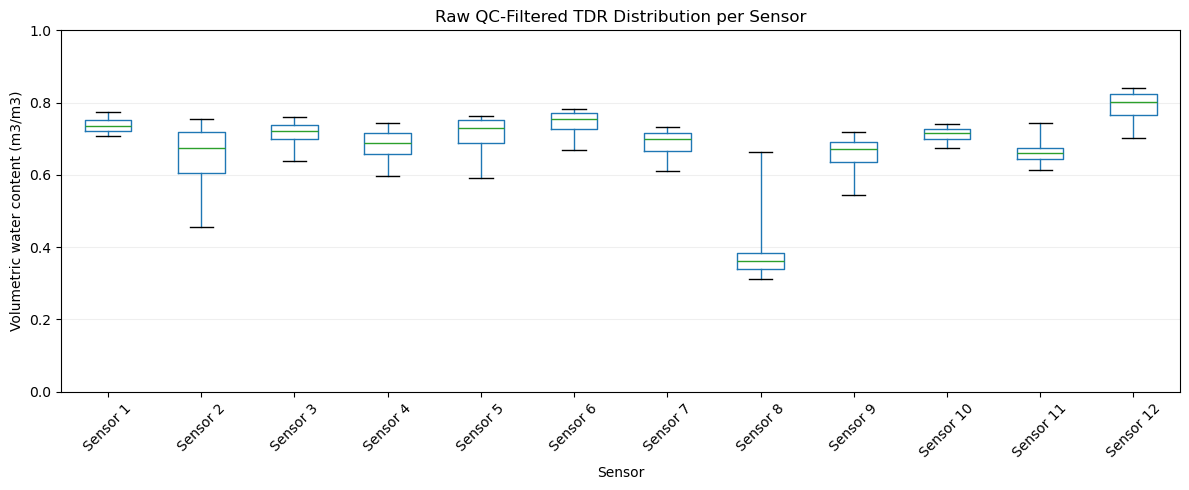

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_sensor_boxplot_daily_weekly_monthly_with21.png


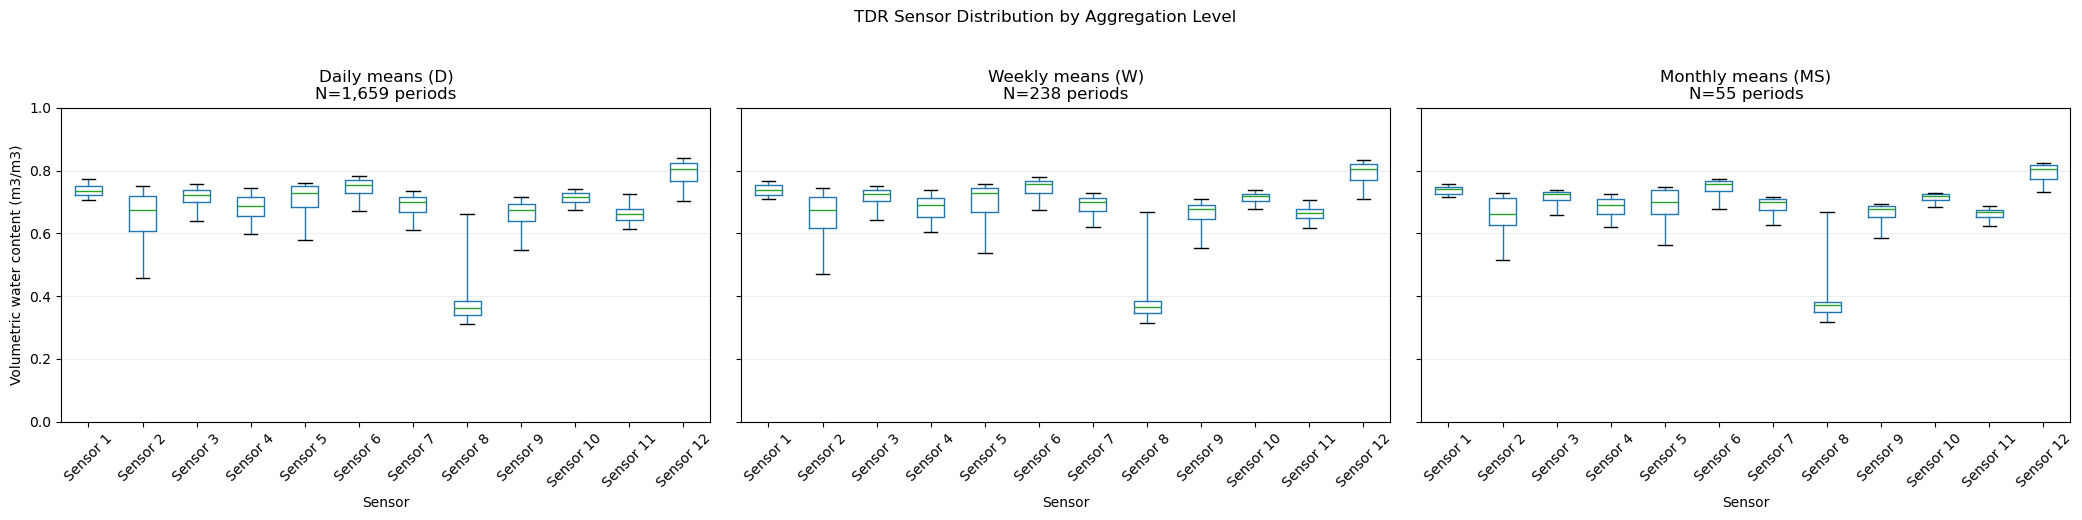

In [3]:
# Inspect and smooth TDR sensor distributions before daily aggregation
df_tdr_raw = pd.read_csv(TDR_RAW_PATH, parse_dates=['TIMESTAMP'])

# Prefer volumetric water-content columns if available; otherwise use numeric sensor-like columns
vw_columns = [column for column in df_tdr_raw.columns if column.lower().startswith('vw')]
if vw_columns:
    sensor_columns = vw_columns
else:
    sensor_columns = [
        column
        for column in df_tdr_raw.select_dtypes(include=[np.number]).columns
        if column.lower() not in {'record'}
    ]

if not sensor_columns:
    raise ValueError('No numeric sensor columns were found in the raw TDR file.')

# Keep all sensors for boxplots, but exclude VW_Avg(21) for downstream SMAP analysis
excluded_sensors = {'VW_Avg(21)'}
analysis_sensor_columns = [column for column in sensor_columns if column not in excluded_sensors]
if not analysis_sensor_columns:
    raise ValueError('No sensors left after applying exclusion list.')

qc_min, qc_max = 0.0, 1.0
sensor_wide_all = (
    df_tdr_raw[['TIMESTAMP'] + sensor_columns]
    .drop_duplicates(subset='TIMESTAMP')
    .sort_values('TIMESTAMP')
    .set_index('TIMESTAMP')
)
sensor_wide_analysis = sensor_wide_all[analysis_sensor_columns]

# Keep only physically plausible volumetric water content values
qc_mask_all = (sensor_wide_all >= qc_min) & (sensor_wide_all <= qc_max)
sensor_wide_qc_all = sensor_wide_all.where(qc_mask_all)

qc_mask_analysis = (sensor_wide_analysis >= qc_min) & (sensor_wide_analysis <= qc_max)
sensor_wide_qc = sensor_wide_analysis.where(qc_mask_analysis)

# Use sequential display labels so the sensor names do not inherit the raw numbering
sensor_display_names = {column: f'Sensor {index}' for index, column in enumerate(sensor_columns, start=1)}
analysis_display_names = {column: sensor_display_names[column] for column in analysis_sensor_columns}
sensor_wide_qc_all_display = sensor_wide_qc_all.rename(columns=sensor_display_names)
sensor_wide_qc_display = sensor_wide_qc.rename(columns=analysis_display_names)

long_all = sensor_wide_qc_all.reset_index().melt(
    id_vars='TIMESTAMP',
    value_vars=sensor_columns,
    var_name='sensor',
    value_name='value'
).dropna(subset=['value'])

invalid_summary = (
    long_all.assign(is_invalid=~long_all['value'].between(qc_min, qc_max))
    .groupby('sensor', as_index=False)
    .agg(
        total_obs=('value', 'size'),
        invalid_obs=('is_invalid', 'sum'),
        min_value=('value', 'min'),
        max_value=('value', 'max')
    )
)
invalid_summary['invalid_pct'] = 100 * invalid_summary['invalid_obs'] / invalid_summary['total_obs']

print(f'Raw rows: {len(df_tdr_raw):,}')
print(f'Sensors available: {len(sensor_columns)}')
print(f'Sensors used in boxplots: {len(sensor_columns)} (includes VW_Avg(21))')
print(f'Sensors used for downstream SMAP analysis: {len(analysis_sensor_columns)}')
print(f'Excluded from downstream SMAP analysis: {sorted(excluded_sensors)}')
print(list(sensor_display_names.values()))
print('\nInvalid-value summary (outside [0, 1]):')
print(invalid_summary.sort_values('invalid_pct', ascending=False).to_string(index=False))

# Smoothed raw boxplot: hide fliers and use percentile whiskers
fig_raw, ax_raw = plt.subplots(figsize=(12, 5))
sensor_wide_qc_all_display.boxplot(
    ax=ax_raw,
    rot=45,
    showfliers=False,
    whis=[5, 95],
    grid=False
)
ax_raw.set_title('Raw QC-Filtered TDR Distribution per Sensor')
ax_raw.set_xlabel('Sensor')
ax_raw.set_ylabel('Volumetric water content (m3/m3)')
ax_raw.set_ylim(qc_min, qc_max)
ax_raw.grid(alpha=0.2, axis='y')
fig_raw.tight_layout()
save_figure(fig_raw, 'results_sm_raw_tdr_sensor_boxplot_smoothed_with21.png')
plt.show()

# Compare aggregation scales to choose smoothing level
aggregation_map = {
    'Daily means (D)': 'D',
    'Weekly means (W)': 'W',
    'Monthly means (MS)': 'MS',
}

fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

for axis, (label, freq) in zip(axes_cmp, aggregation_map.items()):
    aggregated = sensor_wide_qc_all_display.resample(freq).mean()
    aggregated.boxplot(
        ax=axis,
        rot=45,
        showfliers=False,
        whis=[5, 95],
        grid=False
    )
    axis.set_title(f'{label}\nN={len(aggregated):,} periods')
    axis.set_xlabel('Sensor')
    axis.set_ylim(qc_min, qc_max)
    axis.grid(alpha=0.2, axis='y')

axes_cmp[0].set_ylabel('Volumetric water content (m3/m3)')
fig_cmp.suptitle('TDR Sensor Distribution by Aggregation Level', y=1.03)
fig_cmp.tight_layout()
save_figure(fig_cmp, 'results_sm_sensor_boxplot_daily_weekly_monthly_with21.png')
plt.show()

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_sensor_boxplot_with_stats_with21.png


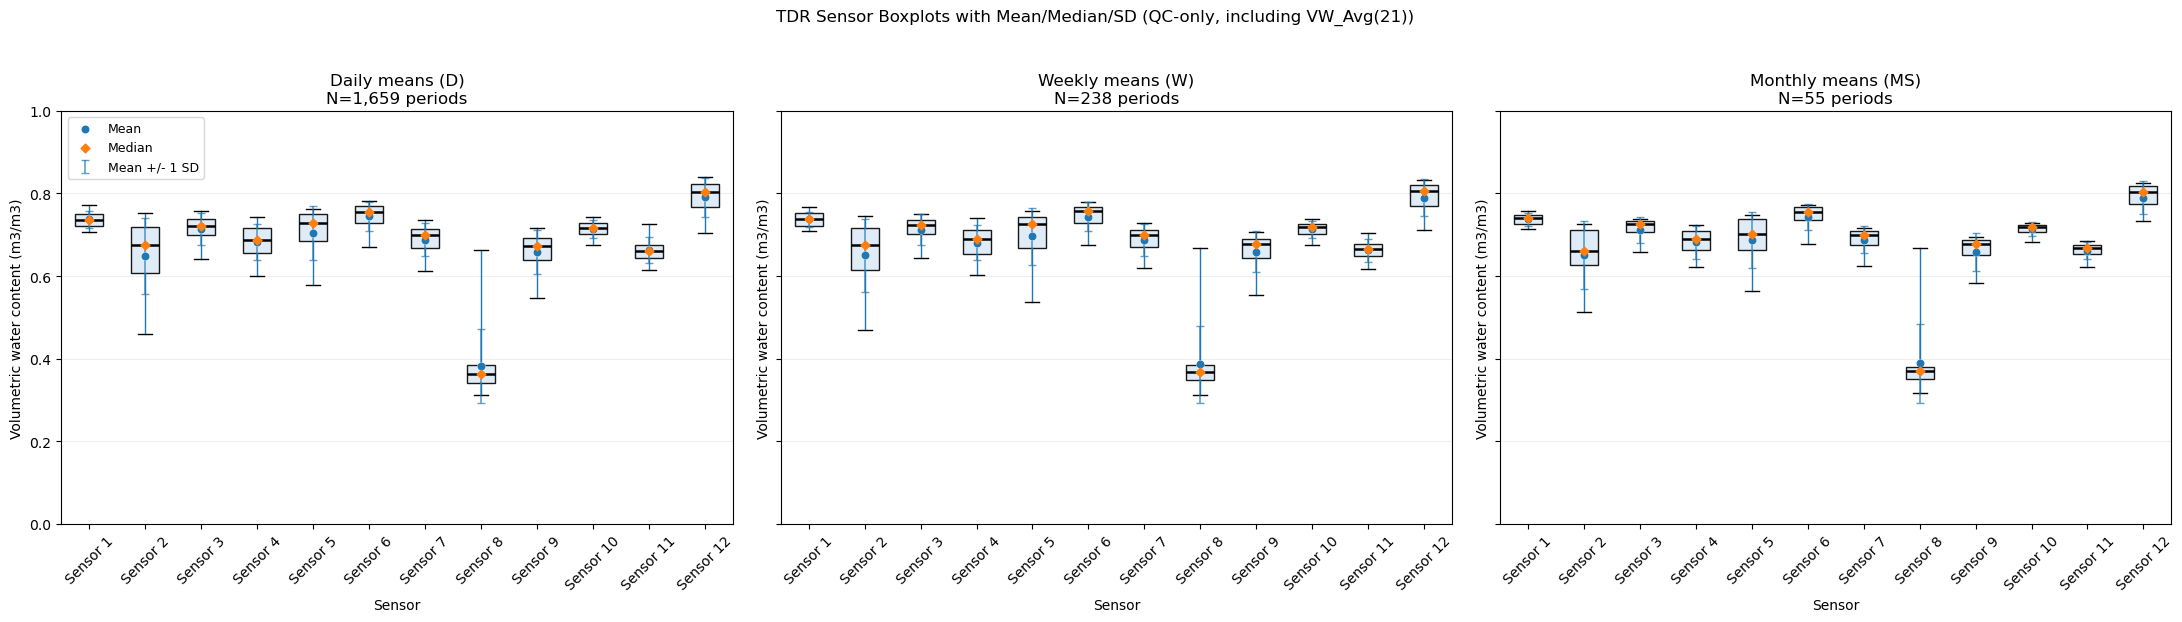

Stats table saved to: C:\Soilgrids\resultados\tdr_sensor_stats_daily_weekly_monthly_with21.csv


,aggregation,sensor,mean,median,std
0,Daily means (D),Sensor 1,0.737442,0.736219,0.020365
1,Daily means (D),Sensor 2,0.649374,0.674726,0.092341
2,Daily means (D),Sensor 3,0.712782,0.721125,0.038756
3,Daily means (D),Sensor 4,0.683312,0.687000,0.043839
4,Daily means (D),Sensor 5,0.704474,0.727868,0.064979
5,Daily means (D),Sensor 6,0.744475,0.754580,0.035677
6,Daily means (D),Sensor 7,0.687752,0.699854,0.039852
7,Daily means (D),Sensor 8,0.382181,0.363365,0.088658
8,Daily means (D),Sensor 9,0.658305,0.672861,0.052564
9,Daily means (D),Sensor 10,0.713190,0.716747,0.021479


In [4]:
# Boxplots with mean, median, and standard deviation annotations for each TDR sensor
if 'sensor_wide_qc_all_display' not in globals() or sensor_wide_qc_all_display.empty:
    raise ValueError("Run Cell 2 first so 'sensor_wide_qc_all_display' is available.")

def plot_box_with_stats(ax, data, title, y_min=0.0, y_max=1.0):
    if data.empty:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        return None

    # Boxplot keeps the median line; mean marker is enabled and outliers are hidden.
    data.boxplot(
        ax=ax,
        rot=45,
        showfliers=False,
        whis=[5, 95],
        showmeans=True,
        meanline=False,
        patch_artist=True,
        boxprops=dict(facecolor='#dceaf7', alpha=0.9),
        medianprops=dict(color='black', linewidth=1.8),
        meanprops=dict(marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=5),
        grid=False
    )

    means = data.mean()
    medians = data.median()
    stds = data.std()
    positions = np.arange(1, len(data.columns) + 1)

    # Overlay explicit symbols and SD bars so statistics are visible in one figure.
    ax.errorbar(
        positions,
        means.values,
        yerr=stds.values,
        fmt='none',
        ecolor='tab:blue',
        elinewidth=1.2,
        capsize=3,
        alpha=0.7,
        label='Mean +/- 1 SD'
    )
    ax.scatter(positions, means.values, color='tab:blue', s=22, zorder=3, label='Mean')
    ax.scatter(positions, medians.values, color='tab:orange', marker='D', s=20, zorder=3, label='Median')

    ax.set_title(f"{title}\nN={len(data):,} periods")
    ax.set_xlabel('Sensor')
    ax.set_ylabel('Volumetric water content (m3/m3)')
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.2, axis='y')

    stats_table = pd.DataFrame({
        'sensor': data.columns,
        'mean': means.values,
        'median': medians.values,
        'std': stds.values
    })

    return stats_table

agg_map = {
    'Daily means (D)': 'D',
    'Weekly means (W)': 'W',
    'Monthly means (MS)': 'MS',
}

fig_stats, axes_stats = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
stats_outputs = []

for idx, (label, freq) in enumerate(agg_map.items()):
    aggregated = sensor_wide_qc_all_display.resample(freq).mean()
    stats_df = plot_box_with_stats(axes_stats[idx], aggregated, label, y_min=qc_min, y_max=qc_max)
    if stats_df is not None:
        stats_df.insert(0, 'aggregation', label)
        stats_outputs.append(stats_df)

# Show a single clean legend
handles, labels = axes_stats[0].get_legend_handles_labels()
if handles:
    axes_stats[0].legend(handles[:3], labels[:3], loc='upper left', fontsize=9)

fig_stats.suptitle('TDR Sensor Boxplots with Mean/Median/SD (QC-only, including VW_Avg(21))', y=1.03)
fig_stats.tight_layout()
save_figure(fig_stats, 'results_sm_sensor_boxplot_with_stats_with21.png')
plt.show()

if stats_outputs:
    stats_summary = pd.concat(stats_outputs, ignore_index=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    stats_summary_path = RESULTS_DIR / 'tdr_sensor_stats_daily_weekly_monthly_with21.csv'
    stats_summary.to_csv(stats_summary_path, index=False)
    print(f'Stats table saved to: {stats_summary_path}')
    display(stats_summary.head(12))

In [5]:
# Compare overall mean including all sensors vs excluding VW_Avg(21) across time scales
if 'df_tdr_raw' not in globals() or df_tdr_raw.empty:
    raise ValueError("Run Cell 2 first so raw TDR data is loaded.")

vw_all = [column for column in df_tdr_raw.columns if column.lower().startswith('vw')]
if 'VW_Avg(21)' not in vw_all:
    raise ValueError('VW_Avg(21) not found in raw VW columns.')

full_sensor_wide = (
    df_tdr_raw[['TIMESTAMP'] + vw_all]
    .drop_duplicates(subset='TIMESTAMP')
    .sort_values('TIMESTAMP')
    .set_index('TIMESTAMP')
)
full_sensor_wide_qc = full_sensor_wide.where((full_sensor_wide >= 0.0) & (full_sensor_wide <= 1.0))

comparisons = []
scale_map = {
    'Raw (all timestamps)': full_sensor_wide_qc,
    'Daily means': full_sensor_wide_qc.resample('D').mean(),
    'Weekly means': full_sensor_wide_qc.resample('W').mean(),
    'Monthly means': full_sensor_wide_qc.resample('MS').mean(),
}

for scale_name, frame in scale_map.items():
    frame = frame.dropna(how='all')
    all_mean = frame.mean(axis=1).mean()
    without_21_mean = frame.drop(columns=['VW_Avg(21)']).mean(axis=1).mean()
    abs_diff = without_21_mean - all_mean
    pct_diff = (abs_diff / all_mean) * 100 if pd.notna(all_mean) and all_mean != 0 else np.nan

    comparisons.append({
        'scale': scale_name,
        'mean_all_sensors': all_mean,
        'mean_without_vw_avg_21': without_21_mean,
        'absolute_difference': abs_diff,
        'percent_difference': pct_diff,
    })

comparison_df = pd.DataFrame(comparisons)
print(comparison_df.to_string(index=False, float_format=lambda value: f'{value:.6f}'))

               scale  mean_all_sensors  mean_without_vw_avg_21  absolute_difference  percent_difference
Raw (all timestamps)          0.675905                0.705330             0.029425            4.353441
         Daily means          0.676134                0.705017             0.028883            4.271778
        Weekly means          0.676438                0.704116             0.027678            4.091705
       Monthly means          0.675939                0.702546             0.026606            3.936220


In [6]:
# Build QC-only TDR daily means (sensor VW_Avg(21) already removed in Cell 2)
if 'sensor_wide_qc_display' not in globals() or sensor_wide_qc_display.empty:
    raise ValueError("Run Cell 2 first so 'sensor_wide_qc_display' is available.")

df_day = sensor_wide_qc_display.resample('D').mean()
df_day.index.name = 'Date'

df_day.to_csv(TDR_DAILY_PATH)

print(f'Daily QC-only sensor averages saved to: {TDR_DAILY_PATH}')
print(f'Shape: {df_day.shape}')
df_day.head()

Daily QC-only sensor averages saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 11)


,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 9,Sensor 10,Sensor 11,Sensor 12
Date,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.686802,0.728819,0.672569,0.826424


In [7]:
# Compute daily mean across QC-filtered sensors (VW_Avg(21) excluded)
df_day_mean = df_day.mean(axis=1).rename('VW_mean_all_sensors').to_frame()
df_day_mean.index.name = 'Date'

df_day_mean.to_csv(TDR_DAILY_MEAN_PATH)

print(f'Saved to: {TDR_DAILY_MEAN_PATH}')
print(f'Shape: {df_day_mean.shape}')
df_day_mean.head()

Saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.721699
2021-09-11,0.724115
2021-09-12,0.740295
2021-09-13,0.749269
2021-09-14,0.736270


In [8]:
# Find missing dates in the daily mean soil moisture series
df_daily = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
df_daily = normalize_dates(df_daily, 'Date')
df_daily = df_daily.drop_duplicates(subset='Date').sort_values('Date').set_index('Date')

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq='D')
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily['VW_mean_all_sensors'].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({'date': all_missing_days.date})
missing_dates_df.to_csv(MISSING_DATES_PATH, index=False)

gap_rows = []
if len(all_missing_days) > 0:
    missing_series = pd.Series(all_missing_days)
    group_id = missing_series.diff().dt.days.ne(1).cumsum()

    for _, group in missing_series.groupby(group_id):
        gap_rows.append({
            'start_date': group.iloc[0].date(),
            'end_date': group.iloc[-1].date(),
            'length_days': int(len(group))
        })

gaps_df = (
    pd.DataFrame(gap_rows).sort_values('length_days', ascending=False)
    if gap_rows
    else pd.DataFrame(columns=['start_date', 'end_date', 'length_days'])
)
gaps_df.to_csv(MISSING_GAPS_PATH, index=False)

print('Missing-date audit complete for daily mean CSV')
print(f'Date range checked: {full_days.min().date()} to {full_days.max().date()}')
print(f'Missing from index: {len(missing_from_index)}')
print(f'NaN days in VW_mean_all_sensors: {len(nan_days)}')
print(f'Total unique missing dates: {len(all_missing_days)}')
print(f'Saved missing dates to: {MISSING_DATES_PATH}')
print(f'Saved gap summary to: {MISSING_GAPS_PATH}')

if len(all_missing_days) > 0:
    print('\nFirst 30 missing dates:')
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print('\nTop 10 largest consecutive missing-date gaps:')
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

Missing-date audit complete for daily mean CSV
Date range checked: 2021-09-10 to 2026-03-26
Missing from index: 0
NaN days in VW_mean_all_sensors: 246
Total unique missing dates: 246
Saved missing dates to: C:\Soilgrids\resultados\missing_dates_daily_mean_all_sensors.csv
Saved gap summary to: C:\Soilgrids\resultados\missing_gaps_summary_daily_mean_all_sensors.csv

First 30 missing dates:
2023-08-04
2023-08-05
2023-08-06
2023-08-07
2023-08-08
2023-08-09
2024-01-26
2024-01-27
2024-01-28
2024-01-29
2024-01-30
2024-01-31
2024-02-01
2024-02-02
2024-02-03
2024-02-04
2024-02-05
2024-02-06
2024-02-07
2024-02-08
2024-02-09
2024-02-10
2024-02-11
2024-02-12
2024-02-13
2024-02-14
2024-02-15
2024-02-16
2024-02-17
2024-02-18

Top 10 largest consecutive missing-date gaps:
start_date   end_date  length_days
2024-03-22 2024-08-15          147
2024-01-26 2024-02-21           27
2026-02-27 2026-03-12           14
2025-11-20 2025-12-03           14
2025-08-29 2025-09-10           13
2025-12-19 2025-12-31 

,start_date,end_date,length_days
2,2024-03-22,2024-08-15,147
1,2024-01-26,2024-02-21,27
7,2026-02-27,2026-03-12,14
5,2025-11-20,2025-12-03,14
4,2025-08-29,2025-09-10,13
6,2025-12-19,2025-12-31,13
3,2025-08-01,2025-08-12,12
0,2023-08-04,2023-08-09,6


In [9]:
# Remove dates with missing data and store a clean result dataframe
df_daily_full = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
missing_dates_df = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])

df_daily_full = normalize_dates(df_daily_full, 'Date')
missing_date_set = set(pd.to_datetime(missing_dates_df['date']).dt.normalize())
known_outlier_dates = {
    pd.Timestamp('2024-11-07'),
    pd.Timestamp('2024-11-14'),
}

df_daily_clean = df_daily_full[~df_daily_full['Date'].isin(missing_date_set)].copy()
df_daily_clean = df_daily_clean[~df_daily_clean['Date'].isin(known_outlier_dates)]
df_daily_clean = df_daily_clean.dropna(subset=['VW_mean_all_sensors'])
df_daily_clean = df_daily_clean.sort_values('Date').reset_index(drop=True)

df_daily_clean.to_csv(TDR_CLEAN_PATH, index=False)

print('Clean dataframe created')
print(f'Original rows: {len(df_daily_full)}')
print(f'Missing dates removed: {len(missing_date_set)}')
print(f'Known outliers removed: {len(known_outlier_dates)}')
print(f'Clean rows: {len(df_daily_clean)}')
print(f'Saved clean dataset to: {TDR_CLEAN_PATH}')

df_daily_clean.head(20)

Clean dataframe created
Original rows: 1659
Missing dates removed: 246
Known outliers removed: 2
Clean rows: 1411
Saved clean dataset to: C:\Soilgrids\resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv


,Date,VW_mean_all_sensors
0,2021-09-10,0.721699
1,2021-09-11,0.724115
2,2021-09-12,0.740295
3,2021-09-13,0.749269
4,2021-09-14,0.736270
5,2021-09-15,0.724513
6,2021-09-16,0.718236
7,2021-09-17,0.713970
8,2021-09-18,0.709876
9,2021-09-19,0.707567


Using existing 'comparison' from current kernel state.
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_linear_regression.png


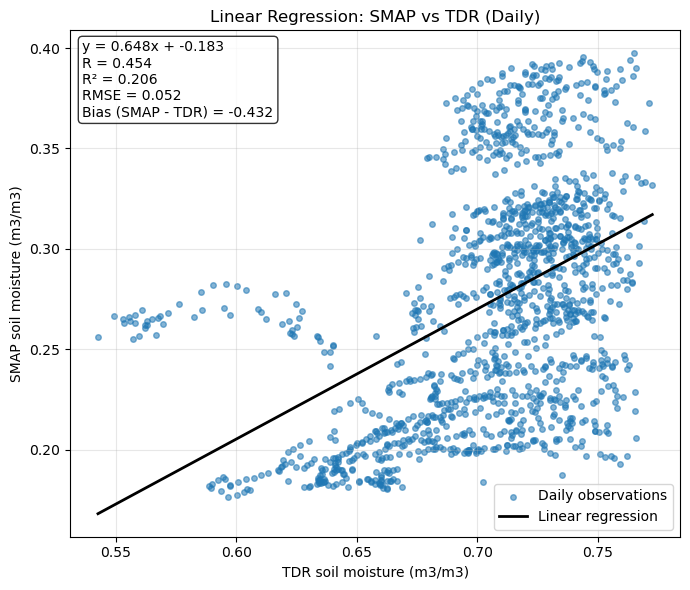

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_exponential_regression.png


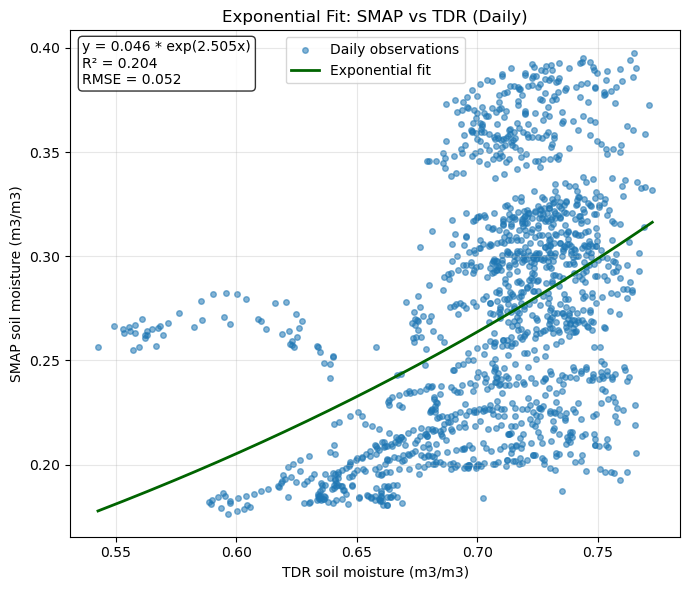

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_quadratic_regression.png


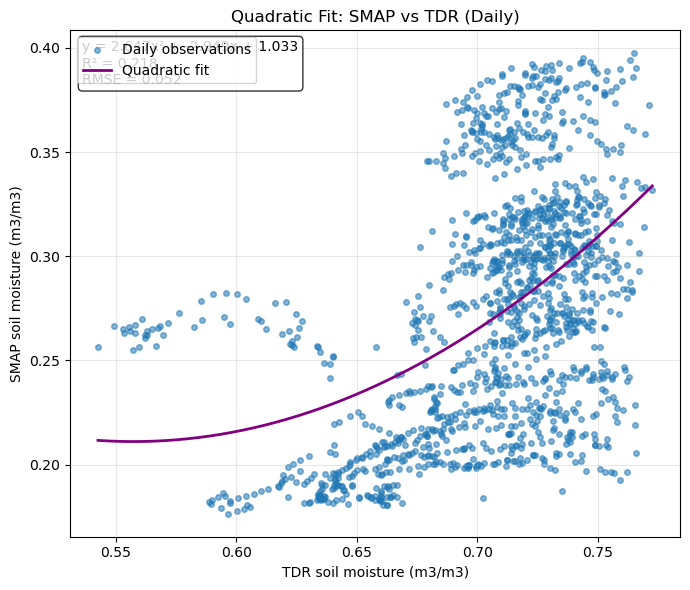

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_model_comparison.png


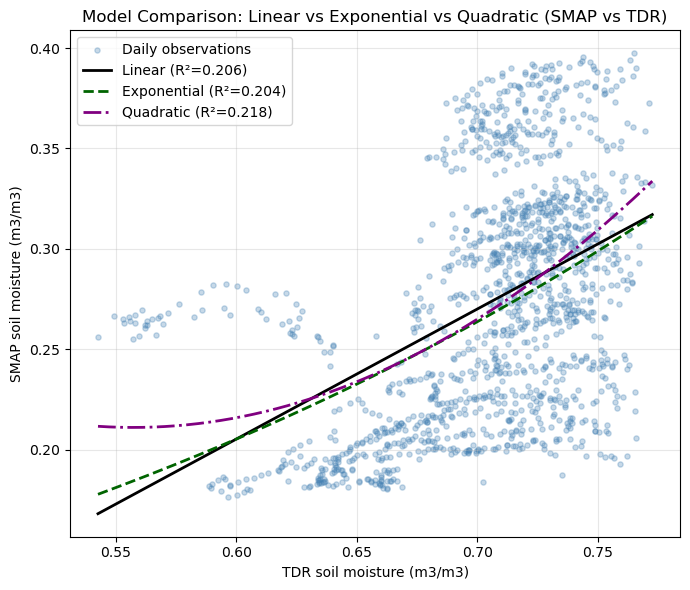

Linear model metrics (direct bias, RMSE, correlation):
Bias (SMAP - TDR): -0.431720
RMSE: 0.052030
Correlation (R): 0.453747
Residual mean (predicted - observed, OLS check): -0.000000

Model comparison (higher R² and lower RMSE are better):


,model,r_squared,rmse,bias_smap_minus_tdr,correlation
0,quadratic,0.217991,0.051632,NaN,NaN
1,linear,0.205886,0.052030,-0.43172,0.453747
2,exponential,0.203909,0.052094,NaN,NaN


In [20]:
# Regression models: linear vs exponential vs quadratic (SMAP vs TDR daily soil moisture)
required_columns = {'Date', 'tdr_soil_moisture', 'smap_soil_moisture'}
if (
    'comparison' not in globals()
    or comparison.empty
    or not required_columns.issubset(set(comparison.columns))
):
    tdr = load_tdr_clean().rename(columns={'VW_mean_all_sensors': 'tdr_soil_moisture'})
    smap_daily = load_smap_daily().rename(columns={'soil_moisture': 'smap_soil_moisture'})

    comparison = pd.merge(tdr, smap_daily, on='Date', how='inner').sort_values('Date')
    comparison = comparison[
        comparison['tdr_soil_moisture'].between(0, 1)
        & comparison['smap_soil_moisture'].between(0, 1)
    ].reset_index(drop=True)

    comparison.to_csv(COMPARISON_DAILY_PATH, index=False)
    print(f"Built 'comparison' automatically from overlap and saved to: {COMPARISON_DAILY_PATH}")
else:
    print("Using existing 'comparison' from current kernel state.")

if len(comparison) < 3:
    raise ValueError("Need at least 3 overlap observations to fit linear/exponential/quadratic models.")

x = comparison['tdr_soil_moisture'].to_numpy()
y = comparison['smap_soil_moisture'].to_numpy()

ss_tot = np.sum((y - np.mean(y)) ** 2)

# Linear model: y = m*x + b
lin_slope, lin_intercept = np.polyfit(x, y, 1)
y_hat_linear = lin_slope * x + lin_intercept
ss_res_linear = np.sum((y - y_hat_linear) ** 2)
r2_linear = 1 - (ss_res_linear / ss_tot) if ss_tot != 0 else np.nan
rmse_linear = np.sqrt(np.mean((y - y_hat_linear) ** 2))
bias_linear_direct = np.mean(y - x)
bias_linear_residual = np.mean(y_hat_linear - y)
corr_linear = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan

# Exponential model: y = a * exp(b*x), fit by log-transform
if np.any(y <= 0):
    raise ValueError('Exponential fit requires strictly positive y values.')
exp_b, ln_exp_a = np.polyfit(x, np.log(y), 1)
exp_a = np.exp(ln_exp_a)
y_hat_exp = exp_a * np.exp(exp_b * x)
ss_res_exp = np.sum((y - y_hat_exp) ** 2)
r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else np.nan
rmse_exp = np.sqrt(np.mean((y - y_hat_exp) ** 2))

# Quadratic model: y = a*x^2 + b*x + c
quad_a, quad_b, quad_c = np.polyfit(x, y, 2)
y_hat_quad = quad_a * x**2 + quad_b * x + quad_c
ss_res_quad = np.sum((y - y_hat_quad) ** 2)
r2_quad = 1 - (ss_res_quad / ss_tot) if ss_tot != 0 else np.nan
rmse_quad = np.sqrt(np.mean((y - y_hat_quad) ** 2))

x_line = np.linspace(x.min(), x.max(), 200)
y_line_linear = lin_slope * x_line + lin_intercept
y_line_exp = exp_a * np.exp(exp_b * x_line)
y_line_quad = quad_a * x_line**2 + quad_b * x_line + quad_c

# Chart 1: linear regression
fig_lin, ax_lin = plt.subplots(figsize=(7, 6))
ax_lin.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_lin.plot(x_line, y_line_linear, color='black', linewidth=2, label='Linear regression')
ax_lin.set_title('Linear Regression: SMAP vs TDR (Daily)')
ax_lin.set_xlabel('TDR soil moisture (m3/m3)')
ax_lin.set_ylabel('SMAP soil moisture (m3/m3)')
ax_lin.grid(alpha=0.3)
ax_lin.legend(loc='best')

lin_text = (
    f"y = {lin_slope:.3f}x + {lin_intercept:.3f}\n"
    f"R = {corr_linear:.3f}\n"
    f"R² = {r2_linear:.3f}\n"
    f"RMSE = {rmse_linear:.3f}\n"
    f"Bias (SMAP - TDR) = {bias_linear_direct:.3f}"
)
ax_lin.text(
    0.02, 0.98, lin_text,
    transform=ax_lin.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)
fig_lin.tight_layout()
save_figure(fig_lin, 'results_sm_tdr_vs_smap_linear_regression.png')
plt.show()

# Chart 2: exponential regression
fig_exp, ax_exp = plt.subplots(figsize=(7, 6))
ax_exp.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_exp.plot(x_line, y_line_exp, color='darkgreen', linewidth=2, label='Exponential fit')
ax_exp.set_title('Exponential Fit: SMAP vs TDR (Daily)')
ax_exp.set_xlabel('TDR soil moisture (m3/m3)')
ax_exp.set_ylabel('SMAP soil moisture (m3/m3)')
ax_exp.grid(alpha=0.3)
ax_exp.legend(loc='best')

exp_text = f"y = {exp_a:.3f} * exp({exp_b:.3f}x)\nR² = {r2_exp:.3f}\nRMSE = {rmse_exp:.3f}"
ax_exp.text(
    0.02, 0.98, exp_text,
    transform=ax_exp.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)
fig_exp.tight_layout()
save_figure(fig_exp, 'results_sm_tdr_vs_smap_exponential_regression.png')
plt.show()

# Chart 3: quadratic regression
fig_quad, ax_quad = plt.subplots(figsize=(7, 6))
ax_quad.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_quad.plot(x_line, y_line_quad, color='purple', linewidth=2, label='Quadratic fit')
ax_quad.set_title('Quadratic Fit: SMAP vs TDR (Daily)')
ax_quad.set_xlabel('TDR soil moisture (m3/m3)')
ax_quad.set_ylabel('SMAP soil moisture (m3/m3)')
ax_quad.grid(alpha=0.3)
ax_quad.legend(loc='best')

quad_text = f"y = {quad_a:.3f}x² + {quad_b:.3f}x + {quad_c:.3f}\nR² = {r2_quad:.3f}\nRMSE = {rmse_quad:.3f}"
ax_quad.text(
    0.02, 0.98, quad_text,
    transform=ax_quad.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)
fig_quad.tight_layout()
save_figure(fig_quad, 'results_sm_tdr_vs_smap_quadratic_regression.png')
plt.show()

# Chart 4: direct model comparison (all fits on one plot)
fig_cmp_fit, ax_cmp_fit = plt.subplots(figsize=(7, 6))
ax_cmp_fit.scatter(x, y, alpha=0.30, s=14, color='steelblue', label='Daily observations')
ax_cmp_fit.plot(x_line, y_line_linear, color='black', linewidth=2, label=f'Linear (R²={r2_linear:.3f})')
ax_cmp_fit.plot(x_line, y_line_exp, color='darkgreen', linewidth=2, linestyle='--', label=f'Exponential (R²={r2_exp:.3f})')
ax_cmp_fit.plot(x_line, y_line_quad, color='purple', linewidth=2, linestyle='-.', label=f'Quadratic (R²={r2_quad:.3f})')
ax_cmp_fit.set_title('Model Comparison: Linear vs Exponential vs Quadratic (SMAP vs TDR)')
ax_cmp_fit.set_xlabel('TDR soil moisture (m3/m3)')
ax_cmp_fit.set_ylabel('SMAP soil moisture (m3/m3)')
ax_cmp_fit.grid(alpha=0.3)
ax_cmp_fit.legend(loc='best')
fig_cmp_fit.tight_layout()
save_figure(fig_cmp_fit, 'results_sm_tdr_vs_smap_model_comparison.png')
plt.show()

model_comparison = pd.DataFrame({
    'model': ['linear', 'exponential', 'quadratic'],
    'r_squared': [r2_linear, r2_exp, r2_quad],
    'rmse': [rmse_linear, rmse_exp, rmse_quad],
    'bias_smap_minus_tdr': [bias_linear_direct, np.nan, np.nan],
    'correlation': [corr_linear, np.nan, np.nan]
}).sort_values('r_squared', ascending=False).reset_index(drop=True)

print('Linear model metrics (direct bias, RMSE, correlation):')
print(f'Bias (SMAP - TDR): {bias_linear_direct:.6f}')
print(f'RMSE: {rmse_linear:.6f}')
print(f'Correlation (R): {corr_linear:.6f}')
print(f'Residual mean (predicted - observed, OLS check): {bias_linear_residual:.6f}')
print('')
print('Model comparison (higher R² and lower RMSE are better):')
display(model_comparison)

Overlap-only SMAP vs TDR
Days used: 1410
Correlation (R): 0.4537
RMSE: 0.4351
Bias (SMAP - TDR): -0.4317
Saved overlap-only table to: C:\Soilgrids\resultados\comparison_smap_vs_tdr_overlap_only.csv
Missing TDR days marked in red: 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_continuous_smap_missing_tdr.png


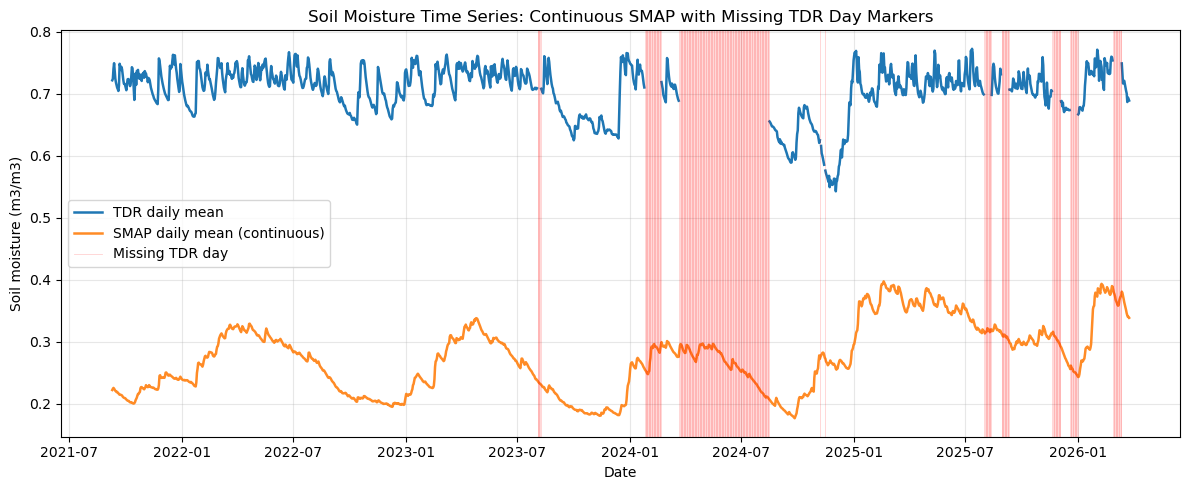

In [ ]:
# Overlap-focused metrics, with continuous SMAP and missing TDR day markers
tdr = load_tdr_clean().rename(columns={'VW_mean_all_sensors': 'tdr_soil_moisture'})
smap_daily = load_smap_daily().rename(columns={'soil_moisture': 'smap_soil_moisture'})

overlap = pd.merge(tdr, smap_daily, on='Date', how='inner').sort_values('Date')
overlap = overlap[
    overlap['tdr_soil_moisture'].between(0, 1)
    & overlap['smap_soil_moisture'].between(0, 1)
]

r_overlap = overlap['tdr_soil_moisture'].corr(overlap['smap_soil_moisture'])
rmse_overlap = np.sqrt(np.mean((overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture']) ** 2))
bias_overlap = np.mean(overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture'])

print('Overlap-only SMAP vs TDR')
print(f'Days used: {len(overlap)}')
print(f'Correlation (R): {r_overlap:.4f}')
print(f'RMSE: {rmse_overlap:.4f}')
print(f'Bias (SMAP - TDR): {bias_overlap:.4f}')

overlap.to_csv(COMPARISON_OVERLAP_PATH, index=False)
print(f'Saved overlap-only table to: {COMPARISON_OVERLAP_PATH}')

plot_timeline = pd.date_range(smap_daily['Date'].min(), smap_daily['Date'].max(), freq='D')
smap_plot = smap_daily.set_index('Date').reindex(plot_timeline)['smap_soil_moisture']

tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src['tdr_soil_moisture'].between(0, 1), 'tdr_soil_moisture'] = np.nan
tdr_plot = tdr_plot_src.set_index('Date').reindex(plot_timeline)['tdr_soil_moisture']

missing_tdr_days = tdr_plot.index[tdr_plot.isna() & smap_plot.notna()]
print(f'Missing TDR days marked in red: {len(missing_tdr_days)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_timeline, tdr_plot, label='TDR daily mean', linewidth=1.8)
ax.plot(plot_timeline, smap_plot, label='SMAP daily mean (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.set_title('Soil Moisture Time Series: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_continuous_smap_missing_tdr.png')
plt.show()

Missing TDR days marked in red (z-score plot): 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_continuous_smap.png


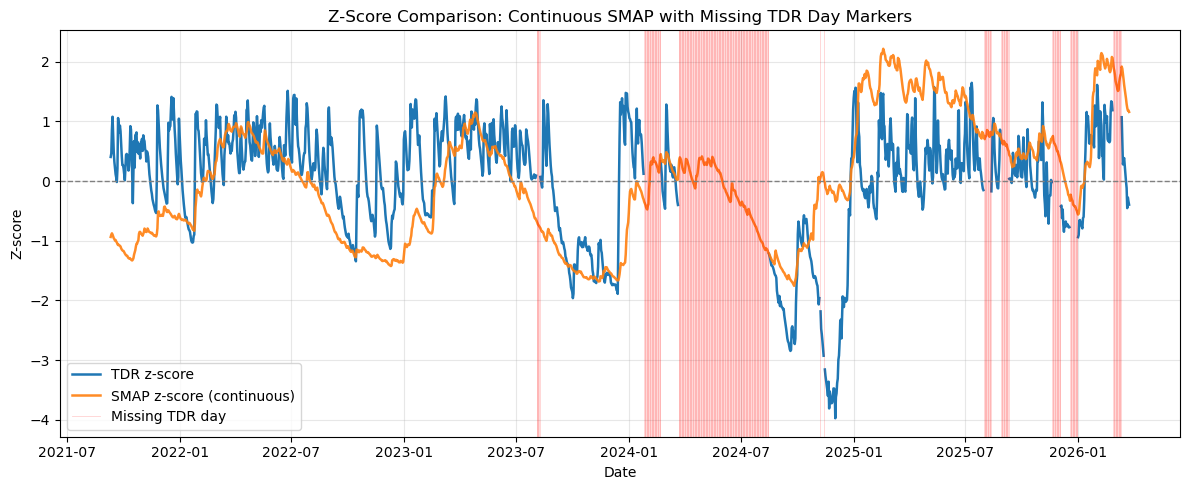

Missing days shown as breaks in overlap-only z-score plot: 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_overlap_only.png


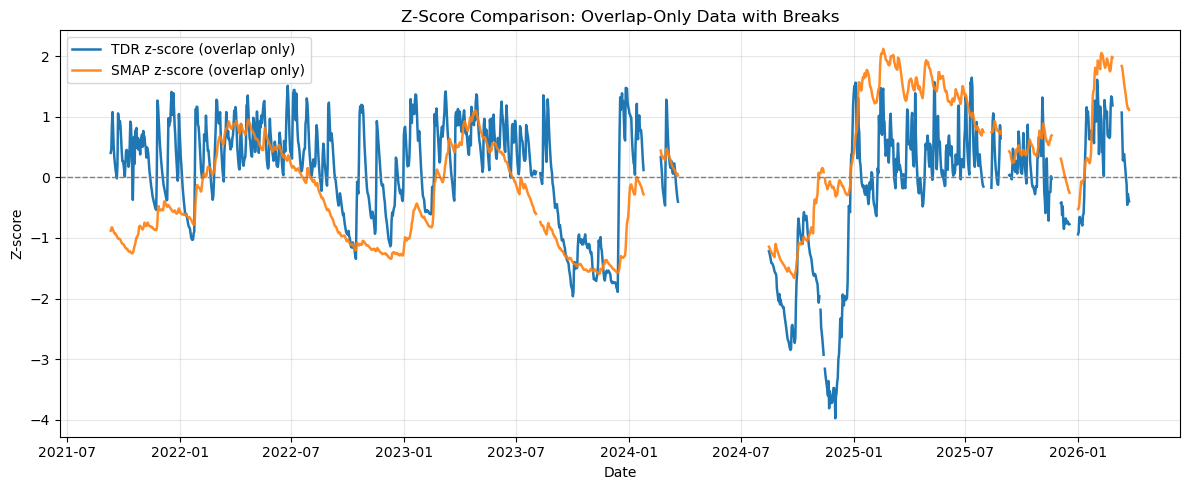

,Date,tdr_z,smap_z
0,2021-09-10,0.403614,-0.879903
1,2021-09-11,0.462675,-0.846362
2,2021-09-12,0.858089,-0.822601
3,2021-09-13,1.077399,-0.842688
4,2021-09-14,0.759715,-0.872633


In [ ]:
# Z-score views for SMAP and TDR
overlap_z = pd.read_csv(COMPARISON_OVERLAP_PATH, parse_dates=['Date']).sort_values('Date')

tdr_z = (overlap_z['tdr_soil_moisture'] - overlap_z['tdr_soil_moisture'].mean()) / overlap_z['tdr_soil_moisture'].std()
smap_z = (overlap_z['smap_soil_moisture'] - overlap_z['smap_soil_moisture'].mean()) / overlap_z['smap_soil_moisture'].std()

z_df = pd.DataFrame({
    'Date': overlap_z['Date'],
    'tdr_z': tdr_z,
    'smap_z': smap_z
}).set_index('Date')

smap_full_daily = load_smap_daily()
smap_full_daily['smap_z_full'] = (
    smap_full_daily['soil_moisture'] - smap_full_daily['soil_moisture'].mean()
 ) / smap_full_daily['soil_moisture'].std()

tdr_clean_full = load_tdr_clean().drop_duplicates(subset='Date').sort_values('Date')
missing_days = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])
missing_days['date'] = pd.to_datetime(missing_days['date']).dt.normalize()
missing_set = set(missing_days['date'])

tdr_values = tdr_clean_full['VW_mean_all_sensors'].where(
    tdr_clean_full['VW_mean_all_sensors'].between(0, 1)
)
tdr_clean_full['tdr_z_full'] = (tdr_values - tdr_values.mean()) / tdr_values.std()

z_timeline = pd.date_range(smap_full_daily['Date'].min(), smap_full_daily['Date'].max(), freq='D')
smap_z_plot = smap_full_daily.set_index('Date').reindex(z_timeline)['smap_z_full']
tdr_z_plot = tdr_clean_full.set_index('Date').reindex(z_timeline)['tdr_z_full']
tdr_z_plot.loc[tdr_z_plot.index.isin(missing_set)] = pd.NA

missing_tdr_days_z = tdr_z_plot.index[tdr_z_plot.isna() & smap_z_plot.notna()]
print(f'Missing TDR days marked in red (z-score plot): {len(missing_tdr_days_z)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline, tdr_z_plot, label='TDR z-score', linewidth=1.8)
ax.plot(z_timeline, smap_z_plot, label='SMAP z-score (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days_z):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_continuous_smap.png')
plt.show()

z_timeline_overlap = pd.date_range(z_df.index.min(), z_df.index.max(), freq='D')
z_plot_overlap = z_df.reindex(z_timeline_overlap)

print(f"Missing days shown as breaks in overlap-only z-score plot: {z_plot_overlap['tdr_z'].isna().sum()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline_overlap, z_plot_overlap['tdr_z'], label='TDR z-score (overlap only)', linewidth=1.8)
ax.plot(z_timeline_overlap, z_plot_overlap['smap_z'], label='SMAP z-score (overlap only)', linewidth=1.8, alpha=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Overlap-Only Data with Breaks')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_overlap_only.png')
plt.show()

z_plot_overlap.reset_index().rename(columns={'index': 'Date'}).head()

Monthly overlap used (both datasets have data): 51 months
Months removed (missing in TDR and/or SMAP): 4
2024-04, 2024-05, 2024-06, 2024-07
Break months rendered for TDR: 4
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_monthly_averages.png


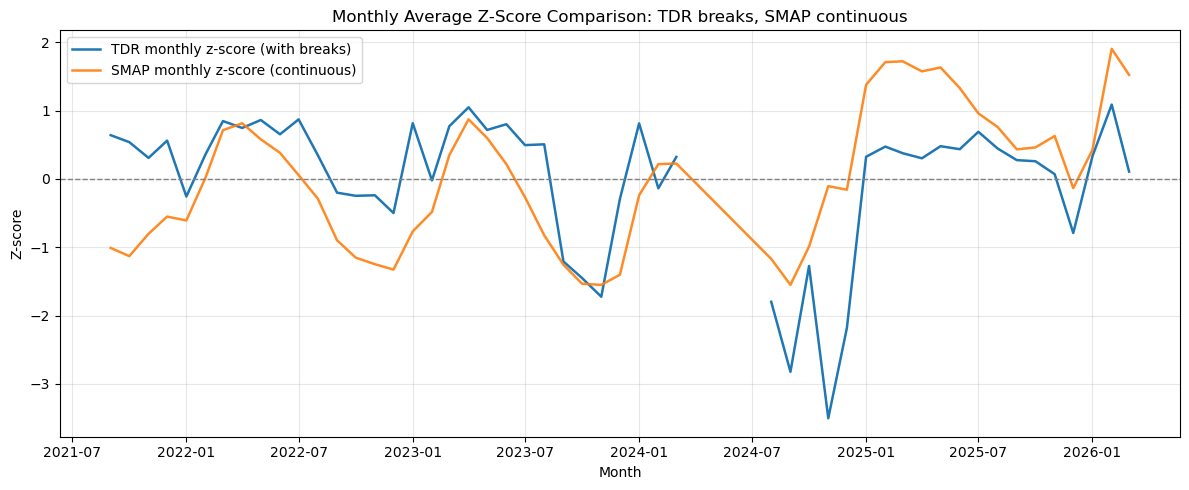

,Month,tdr_monthly_mean,tdr_obs_count,smap_monthly_mean,smap_obs_count,tdr_monthly_z,smap_monthly_z
0,2021-09-01,0.726807,21.0,0.217048,21,0.639425,-1.010547
1,2021-10-01,0.723288,31.0,0.210204,31,0.537431,-1.130308
2,2021-11-01,0.715335,30.0,0.228883,30,0.306966,-0.803463
3,2021-12-01,0.724057,31.0,0.243277,31,0.559727,-0.551593
4,2022-01-01,0.695830,31.0,0.240050,31,-0.258288,-0.608058


In [18]:
# Monthly-average z-score comparison for TDR and SMAP (exclude months with no data)
tdr_monthly = load_tdr_clean().copy()
tdr_monthly['Month'] = tdr_monthly['Date'].dt.to_period('M').dt.to_timestamp()
tdr_monthly = (
    tdr_monthly.groupby('Month', as_index=False)
    .agg(
        tdr_monthly_mean=('VW_mean_all_sensors', 'mean'),
        tdr_obs_count=('VW_mean_all_sensors', 'count')
    )
)

smap_monthly = load_smap_daily().copy()
smap_monthly['Month'] = smap_monthly['Date'].dt.to_period('M').dt.to_timestamp()
smap_monthly = (
    smap_monthly.groupby('Month', as_index=False)
    .agg(
        smap_monthly_mean=('soil_moisture', 'mean'),
        smap_obs_count=('soil_moisture', 'count')
    )
)

monthly_all = pd.merge(tdr_monthly, smap_monthly, on='Month', how='outer').sort_values('Month')
valid_mask = (monthly_all['tdr_obs_count'].fillna(0) > 0) & (monthly_all['smap_obs_count'].fillna(0) > 0)
monthly_comparison = monthly_all.loc[valid_mask].copy().reset_index(drop=True)
removed_months = monthly_all.loc[~valid_mask, 'Month'].dropna().sort_values().dt.strftime('%Y-%m').tolist()

if monthly_comparison.empty:
    raise ValueError('No months with data in both TDR and SMAP after filtering.')

tdr_std = monthly_comparison['tdr_monthly_mean'].std()
smap_std = monthly_comparison['smap_monthly_mean'].std()
monthly_comparison['tdr_monthly_z'] = (
    (monthly_comparison['tdr_monthly_mean'] - monthly_comparison['tdr_monthly_mean'].mean()) / tdr_std
    if pd.notna(tdr_std) and tdr_std != 0
    else np.nan
)
monthly_comparison['smap_monthly_z'] = (
    (monthly_comparison['smap_monthly_mean'] - monthly_comparison['smap_monthly_mean'].mean()) / smap_std
    if pd.notna(smap_std) and smap_std != 0
    else np.nan
)

# Reindex only TDR to full monthly timeline so missing months appear as NaN breaks.
full_month_index = pd.date_range(
    monthly_all['Month'].min(),
    monthly_all['Month'].max(),
    freq='MS'
)
tdr_plot = (
    monthly_comparison[['Month', 'tdr_monthly_z']]
    .set_index('Month')
    .reindex(full_month_index)
)
tdr_plot.index.name = 'Month'

# Keep SMAP continuous by plotting overlap-month points without NaN reindexing.
smap_plot = monthly_comparison[['Month', 'smap_monthly_z']].set_index('Month')

print(f"Monthly overlap used (both datasets have data): {len(monthly_comparison)} months")
print(f"Months removed (missing in TDR and/or SMAP): {len(removed_months)}")
if removed_months:
    print(', '.join(removed_months))
print(f"Break months rendered for TDR: {tdr_plot['tdr_monthly_z'].isna().sum()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    tdr_plot.index,
    tdr_plot['tdr_monthly_z'],
    label='TDR monthly z-score (with breaks)',
    linewidth=1.8
)
ax.plot(
    smap_plot.index,
    smap_plot['smap_monthly_z'],
    label='SMAP monthly z-score (continuous)',
    linewidth=1.8,
    alpha=0.9
)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Monthly Average Z-Score Comparison: TDR breaks, SMAP continuous')
ax.set_xlabel('Month')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_monthly_averages.png')
plt.show()

monthly_comparison.head()

Monthly overlap used for raw plot: 51 months
Missing months highlighted in red: 4
2024-04, 2024-05, 2024-06, 2024-07
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_monthly_raw_with_red_breaks.png


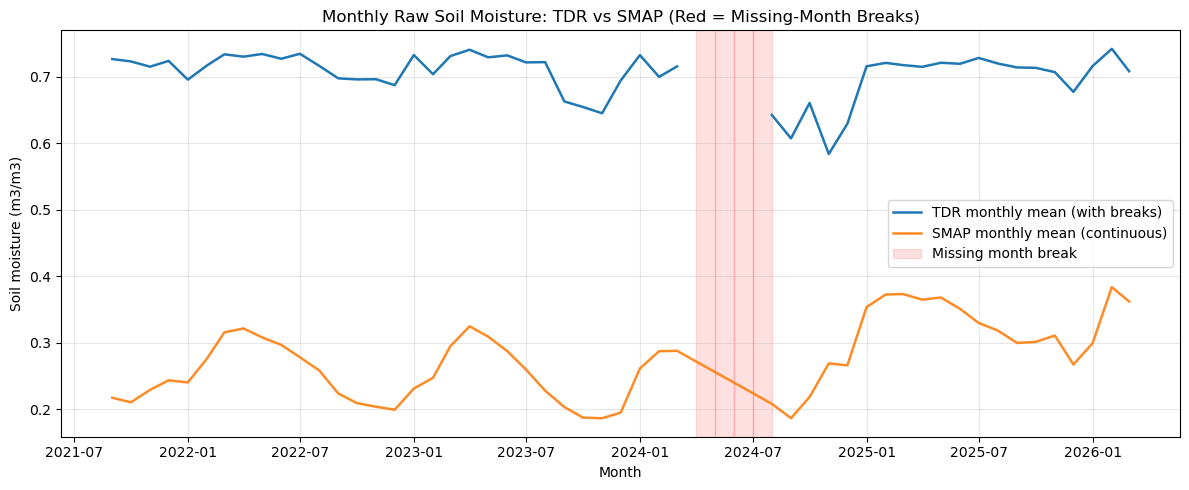

,Month,tdr_monthly_mean,tdr_obs_count,smap_monthly_mean,smap_obs_count
0,2021-09-01,0.726807,21.0,0.217048,21
1,2021-10-01,0.723288,31.0,0.210204,31
2,2021-11-01,0.715335,30.0,0.228883,30
3,2021-12-01,0.724057,31.0,0.243277,31
4,2022-01-01,0.695830,31.0,0.240050,31


In [22]:
# Monthly raw soil moisture comparison (no z-score) with red break markers for missing months
tdr_monthly_raw = load_tdr_clean().copy()
tdr_monthly_raw['Month'] = tdr_monthly_raw['Date'].dt.to_period('M').dt.to_timestamp()
tdr_monthly_raw = (
    tdr_monthly_raw.groupby('Month', as_index=False)
    .agg(
        tdr_monthly_mean=('VW_mean_all_sensors', 'mean'),
        tdr_obs_count=('VW_mean_all_sensors', 'count')
    )
)

smap_monthly_raw = load_smap_daily().copy()
smap_monthly_raw['Month'] = smap_monthly_raw['Date'].dt.to_period('M').dt.to_timestamp()
smap_monthly_raw = (
    smap_monthly_raw.groupby('Month', as_index=False)
    .agg(
        smap_monthly_mean=('soil_moisture', 'mean'),
        smap_obs_count=('soil_moisture', 'count')
    )
)

monthly_all_raw = pd.merge(tdr_monthly_raw, smap_monthly_raw, on='Month', how='outer').sort_values('Month')
valid_mask_raw = (monthly_all_raw['tdr_obs_count'].fillna(0) > 0) & (monthly_all_raw['smap_obs_count'].fillna(0) > 0)
monthly_raw = monthly_all_raw.loc[valid_mask_raw].copy().reset_index(drop=True)

if monthly_raw.empty:
    raise ValueError('No monthly overlap available for raw monthly plot.')

removed_months_raw = monthly_all_raw.loc[~valid_mask_raw, 'Month'].dropna().sort_values()

full_month_index_raw = pd.date_range(
    monthly_all_raw['Month'].min(),
    monthly_all_raw['Month'].max(),
    freq='MS'
)
tdr_raw_plot = (
    monthly_raw[['Month', 'tdr_monthly_mean']]
    .set_index('Month')
    .reindex(full_month_index_raw)
)
tdr_raw_plot.index.name = 'Month'

# Keep SMAP continuous over available overlap months.
smap_raw_plot = monthly_raw[['Month', 'smap_monthly_mean']].set_index('Month')

print(f"Monthly overlap used for raw plot: {len(monthly_raw)} months")
print(f"Missing months highlighted in red: {len(removed_months_raw)}")
if len(removed_months_raw) > 0:
    print(', '.join(removed_months_raw.dt.strftime('%Y-%m').tolist()))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    tdr_raw_plot.index,
    tdr_raw_plot['tdr_monthly_mean'],
    label='TDR monthly mean (with breaks)',
    linewidth=1.8
)
ax.plot(
    smap_raw_plot.index,
    smap_raw_plot['smap_monthly_mean'],
    label='SMAP monthly mean (continuous)',
    linewidth=1.8,
    alpha=0.9
)

for idx, missing_month in enumerate(removed_months_raw):
    start = pd.Timestamp(missing_month)
    end = start + pd.offsets.MonthBegin(1)
    ax.axvspan(
        start,
        end,
        color='red',
        alpha=0.12,
        label='Missing month break' if idx == 0 else None
    )

ax.set_title('Monthly Raw Soil Moisture: TDR vs SMAP (Red = Missing-Month Breaks)')
ax.set_xlabel('Month')
ax.set_ylabel('Soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_monthly_raw_with_red_breaks.png')
plt.show()

monthly_raw.head()

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_monthly_mean_bias_histogram.png


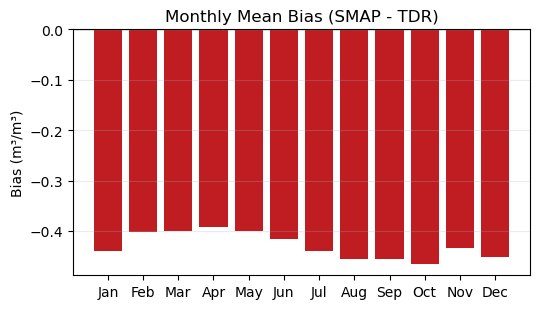

,month,bias
0,Jan,-0.440176
1,Feb,-0.402361
2,Mar,-0.399918
3,Apr,-0.391956
4,May,-0.400136
5,Jun,-0.414990
6,Jul,-0.439355
7,Aug,-0.455221
8,Sep,-0.456035
9,Oct,-0.464597


In [19]:
# Histogram-style bar chart of monthly mean bias (SMAP - TDR)
tdr_bias = load_tdr_clean().rename(columns={'VW_mean_all_sensors': 'tdr_soil_moisture'})
smap_bias = load_smap_daily().rename(columns={'soil_moisture': 'smap_soil_moisture'})

bias_daily = pd.merge(tdr_bias, smap_bias, on='Date', how='inner').sort_values('Date')
bias_daily = bias_daily[
    bias_daily['tdr_soil_moisture'].between(0, 1)
    & bias_daily['smap_soil_moisture'].between(0, 1)
].copy()

if bias_daily.empty:
    raise ValueError('No overlap data available to compute monthly mean bias.')

bias_daily['bias'] = bias_daily['smap_soil_moisture'] - bias_daily['tdr_soil_moisture']
bias_daily['month_num'] = bias_daily['Date'].dt.month

month_lookup = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

monthly_mean_bias = (
    bias_daily.groupby('month_num', as_index=False)['bias']
    .mean()
    .sort_values('month_num')
)
monthly_mean_bias['month'] = monthly_mean_bias['month_num'].map(month_lookup)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(monthly_mean_bias['month'], monthly_mean_bias['bias'], color='#bf1d22', width=0.8)
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Monthly Mean Bias (SMAP - TDR)')
ax.set_ylabel('Bias (m³/m³)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

save_figure(fig, 'results_sm_monthly_mean_bias_histogram.png')
plt.show()

display(monthly_mean_bias[['month', 'bias']])